This notebook creates visuals which relate the corrected historical precipitation implemented by each model to their runoff projections. The data has been processed elsewhere.

Last edited: June 7, 2024 | FFW

Loading in precip data:

In [1]:
import numpy as np
import pandas as pd
from datetime import date
import collections
import datetime
import os
import xarray as xr
import csv
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
import itertools
import glob
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression

## Generic the filepath to the main data folder
fpath1 = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/Precipitation Analysis/'
gmodels = ['GloGEM', 'PyGEM', 'OGGM']

In [2]:
file_pattern = os.path.join(fpath1, f"precip_*.csv")
file_list = glob.glob(file_pattern)

dfs = []  # List to store DataFrames

for file, gmodel in zip(file_list, ['OGGM', 'PyGEM', 'GloGEM']):
    temp_df = pd.read_csv(file, index_col=0)
    temp_df.columns = [gmodel]  # Rename column to gmodel
    dfs.append(temp_df)  # Append each DataFrame to the list

all_precip_data = pd.concat(dfs, axis=1)*1e-9  #Converting m^3 to km^3

In [3]:
all_precip_data

,OGGM,PyGEM,GloGEM
RHINE,1.478006,0.894929,1.080036
RHONE,2.912775,1.879688,2.562059
PO,1.060469,0.662404,0.850126
DANUBE,1.371051,0.872527,1.006785
TITICACA,0.916983,0.391223,0.516107
...,...,...,...
GANGES,38.690701,7.803995,18.560762
BRAHMAPUTRA,33.691514,18.723593,25.838409
OB,1.429362,1.214789,1.423324
INDIGIRKA,0.272789,0.200560,0.229476


In [4]:
#Exporting as a CSV
output_dir = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/Precipitation Analysis/'

fname = 'Avg_Annual_Prcp_2000-2019.csv'

# Define the full path of the output file
output_path = os.path.join(output_dir, fname)

# Save the DataFrame as CSV
all_precip_data.to_csv(output_path, header=True, index=True)

In [5]:
all_precip_data.loc['GANGES']

OGGM      38.690701
PyGEM      7.803995
GloGEM    18.560762
Name: GANGES, dtype: float64

In [6]:
38.690701/7.803995

4.9578069950070445

In [7]:
all_precip_data.loc['SERRANO']

OGGM      2.599379
PyGEM     2.401522
GloGEM    7.353654
Name: SERRANO, dtype: float64

In [8]:
7.353654/2.401522

3.06208063053347

In [9]:
# Calculate mean value for each basin across the gmodels
prcp_means = all_precip_data.mean(axis=1)

# Normalize values for each gmodel by dividing by the mean
normalized_prcp_values = all_precip_data.divide(prcp_means, axis=0)

Loading in RMQ data:

In [10]:
# Create an empty dictionary to store RMQ DataFrames for each GCM and SSP
fpath0 = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/'

scenarios = ['ssp126','ssp245','ssp370','ssp585']

modelnames = ['BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 
                  'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']
RMQ = {}   
for s, SSP in enumerate(scenarios):
    RMQ[SSP] = {}
    for m, GCM in enumerate(modelnames):
        
        file = f"RMQ{GCM}_{SSP}.csv"
        temp_df = pd.read_csv(fpath0 + 'RMQ/'+ file, index_col=0)
    
        # Store the combined_df in the dictionary for each SSP
        RMQ[SSP][GCM] = temp_df

In [11]:
#Create new dict to store multi-GCM means
RMQ_GCM_means = {}
for g, gmodel in enumerate(gmodels):
    RMQ_GCM_means[gmodel] = {}
    for s, SSP in enumerate(scenarios):
        all_GCMs = []
        for m, GCM in enumerate(modelnames):
            all_GCMs.append(RMQ[SSP][GCM][gmodel])
            
        # Calculate the mean for each year across the models
        temp_df = pd.DataFrame(all_GCMs)
        RMQ_GCM_means[gmodel][SSP] = temp_df.mean(axis = 0)

In [12]:
# Adjusting data structure to match precip data
RMQs = {}

for SSP in scenarios:
    SSP_data = {}
    for gmodel in gmodels:
        gmodel_data = RMQ_GCM_means[gmodel][SSP]
        SSP_data[gmodel] = gmodel_data
        
    # Create DataFrame for the SSP
    SSP_df = pd.DataFrame(SSP_data)
    
    # Store DataFrame in the restructured dictionary
    RMQs[SSP] = SSP_df

Plotting RMQ vs normalized precipitation:

In [13]:
chosen_SSP = 'ssp245'
# Remove specified basins
rmq_data = RMQs[chosen_SSP]#.drop(index=basins_to_remove, errors='ignore')
precip_data = normalized_prcp_values#.drop(index=basins_to_remove, errors='ignore')

combined_data = {}

for gmodel in precip_data.keys():
    x = precip_data[gmodel].values.reshape(-1, 1)
    y = rmq_data[gmodel]
    combined_data[gmodel] = pd.DataFrame({'Precipitation': x.flatten(), 'RMQ': y})

# Concatenate all DataFrames into a single one
combined_df = pd.concat(combined_data.values(), keys=combined_data.keys())

# Reset index
combined_df.reset_index(level=0, inplace=True)
combined_df.rename(columns={'level_0': 'GModel'}, inplace=True)

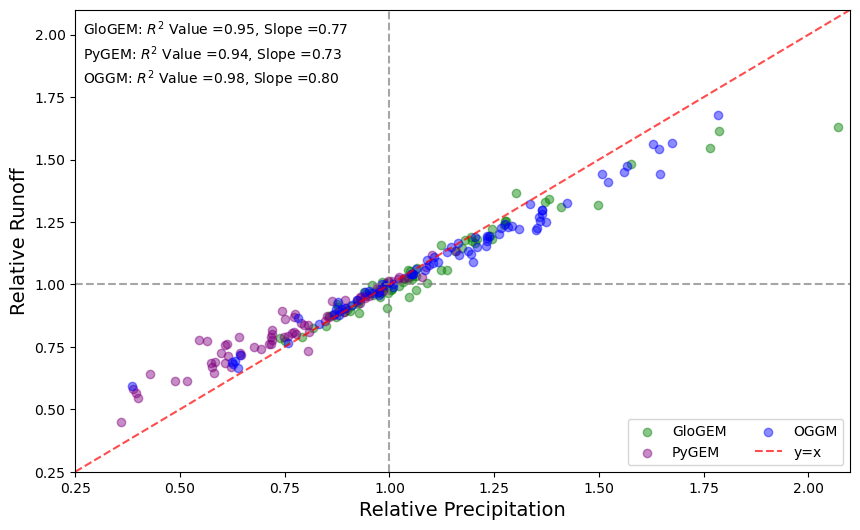

In [14]:
chosen_SSP = 'ssp245'

# Create scatter plot
plt.figure(figsize=(10, 6))

# Remove specified basins
rmq_data = RMQs[chosen_SSP]#.drop(index=basins_to_remove, errors='ignore')
precip_data = normalized_prcp_values#.drop(index=basins_to_remove, errors='ignore')

# List to store correlation coefficients and p-values
regression_results = []

# Scatter plot for each gmodel
for gmodel, color in zip(gmodels, ['green', 'purple', 'blue']):
    x = precip_data[gmodel].values.reshape(-1, 1)
    y = rmq_data[gmodel]
    plt.scatter(x, y, color=color, label=gmodel, alpha = 0.45)  # Add label for legend

    # Perform linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    
    # Calculate R^2 value
    r_squared = model.score(x, y)
    
    # Get slope of the line of best fit
    slope = model.coef_[0]

    regression_results.append({'Glacier Model': gmodel, 'R^2 Value': r_squared, 'Slope': slope})

# Convert the list of dictionaries to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Annotate correlation coefficients and p-values in the upper left corner
text = '\n'.join(f"{row['Glacier Model']}: $R^2$ Value ={row['R^2 Value']:.2f}, Slope ={row['Slope']:.2f}" for index, row in regression_df.iterrows())
plt.text(0.01, 0.98, text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Add grey dotted lines passing through x=1 and y=1
plt.axvline(x=1, color='grey', linestyle='--', alpha = 0.7)
plt.axhline(y=1, color='grey', linestyle='--', alpha = 0.7)
plt.plot([0.25, 2.1], [0.25, 2.1], color='red', linestyle='--', label='y=x', alpha = 0.7)

# Plot labels and legend
plt.xlabel('Relative Precipitation', fontsize = 14)
plt.ylabel('Relative Runoff', fontsize = 14)
#plt.title('Relative Precipitation vs. Relative Runoff', y = 1.08)

# Add a line with slope=1 and y-intercept=0

# Set same limits for x and y axes
plt.xlim(0.25, 2.1)
plt.ylim(0.25, 2.1)

# Modify legend to have three columns and position it above the plot
plt.legend(ncol=2, loc='lower right', bbox_to_anchor=(1, 0))

name = 'relativeRF_vs_relativePRCP'
plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/{name}.png", dpi=600, bbox_inches='tight')

plt.show()

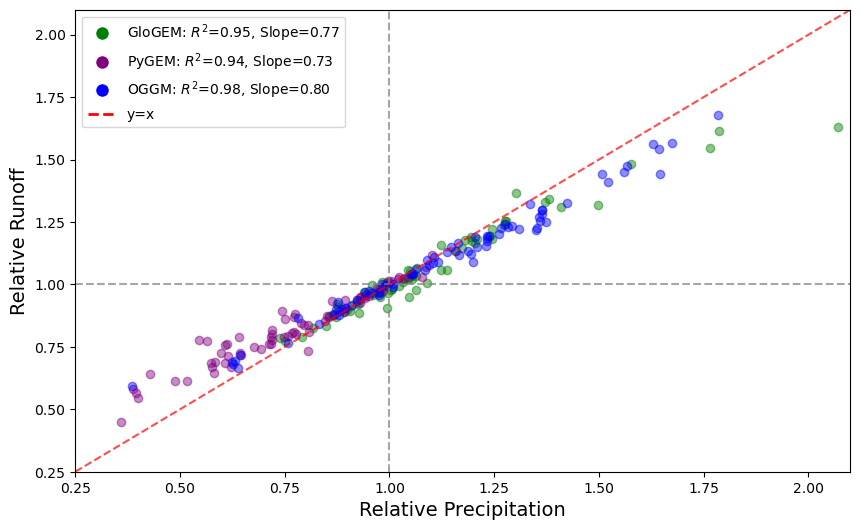

In [15]:
from matplotlib.lines import Line2D
chosen_SSP = 'ssp245'

# Create scatter plot
plt.figure(figsize=(10, 6))

# Remove specified basins
rmq_data = RMQs[chosen_SSP]  # .drop(index=basins_to_remove, errors='ignore')
precip_data = normalized_prcp_values  # .drop(index=basins_to_remove, errors='ignore')

# List to store correlation coefficients and p-values
regression_results = []

# Scatter plot for each gmodel
for gmodel, color in zip(gmodels, ['green', 'purple', 'blue']):
    x = precip_data[gmodel].values.reshape(-1, 1)
    y = rmq_data[gmodel]
    plt.scatter(x, y, color=color, label=gmodel, alpha=0.45)  # Add label for legend

    # Perform linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    
    # Calculate R^2 value
    r_squared = model.score(x, y)
    
    # Get slope of the line of best fit
    slope = model.coef_[0]

    regression_results.append({'Glacier Model': gmodel, 'R^2 Value': r_squared, 'Slope': slope})

# Convert the list of dictionaries to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Add grey dotted lines passing through x=1 and y=1
plt.axvline(x=1, color='grey', linestyle='--', alpha=0.7)
plt.axhline(y=1, color='grey', linestyle='--', alpha=0.7)
plt.plot([0.25, 2.1], [0.25, 2.1], color='red', linestyle='--', label='y=x', alpha=0.7)

# Plot labels and legend
plt.xlabel('Relative Precipitation', fontsize=14)
plt.ylabel('Relative Runoff', fontsize=14)
#plt.title('Relative Precipitation vs. Relative Runoff', y=1.08)

# Set same limits for x and y axes
plt.xlim(0.25, 2.1)
plt.ylim(0.25, 2.1)

# Create custom legend entries
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f"{row['Glacier Model']}: $R^2$={row['R^2 Value']:.2f}, Slope={row['Slope']:.2f}", 
           markerfacecolor=color, markersize=10) 
    for (index, row), color in zip(regression_df.iterrows(), ['green', 'purple', 'blue'])
]
legend_elements.append(Line2D([0], [0], color='red', lw=2, linestyle='--', label='y=x'))

# Add custom legend entries
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), fontsize=10, ncol=1)

# Save and show the plot
name = 'relativeRF_vs_relativePRCP'
plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/{name}.pdf", dpi=300, bbox_inches='tight')

plt.show()

In [27]:
basins = RMQs[chosen_SSP].index.tolist()

basin_to_region = {
    'ALSEK': 1, 'COLUMBIA': 2, 'COLVILLE': 1, 'COPPER': 1, 'FRASER': 2,
    'KUSKOKWIM': 1, 'MACKENZIE': 2, 'NASS': 1, 'NUSHAGAK': 1, 'NELSON': 2,
    'SKAGIT': 2, 'SKEENA': 2, 'STIKINE': 1, 'SUSITNA': 1, 'TAKU': 1,
    'YUKON': 1,

    'DANUBE': 11, 'DRAMSELVA': 8, 'GLOMAA': 8, 'JOKULSA A FJOLLUM': 6, 'KALIXALVEN': 8,
    'LAGARFLJOT': 6, 'LULEALVEN': 8, 'OLFUSA': 6, 'PO': 11, 'RHINE': 11,
    'RHONE': 11, 'SVARTA': 6, 'THJORSA': 6, 'TORNEALVEN': 8,

    'ARAL SEA': 14, 'BRAHMAPUTRA': 15, 'CHUY': 13, 'HAR US NUUR': 10, 'GANGES': 15,
    'INDIGIRKA': 10, 'INDUS': 14, 'IRRAWADDY': 15, 'KAMCHATKA': 10, 'KUBAN': 12,
    'LAKE BALKHASH': 13, 'MEKONG': 13, 'OB': 10, 'SALWEEN': 15, 'TALAS': 13, 'TARIM HE': 14,
    'UVS NUUR': 10, 'YANGTZE': 15, 'YELLOW RIVER': 13, 'YSYK-KOL': 13,

    'AISEN': 17, 'AMAZON': 16, 'AZOPARDO': 17, 'BAKER': 17,
    'BIOBIO': 17, 'CHICO': 17, 'CISNES': 17, 'COLORADO': 17,
    'COPIAPO': 17, 'HUASCO': 17, 'MAGDALENA': 16, 'MAJES': 16,
    'NEGRO': 17, 'OCONA': 16, 'PALENA': 17, 'PASCUA': 17,
    'PUELO': 17, 'RAPEL': 17, 'SANTA': 16, 'SANTA CRUZ': 17,
    'SERRANO': 17, 'TITICACA': 16, 'VALDIVIA': 17, 'YELCHO': 17,

    'CLUTHA': 18
}

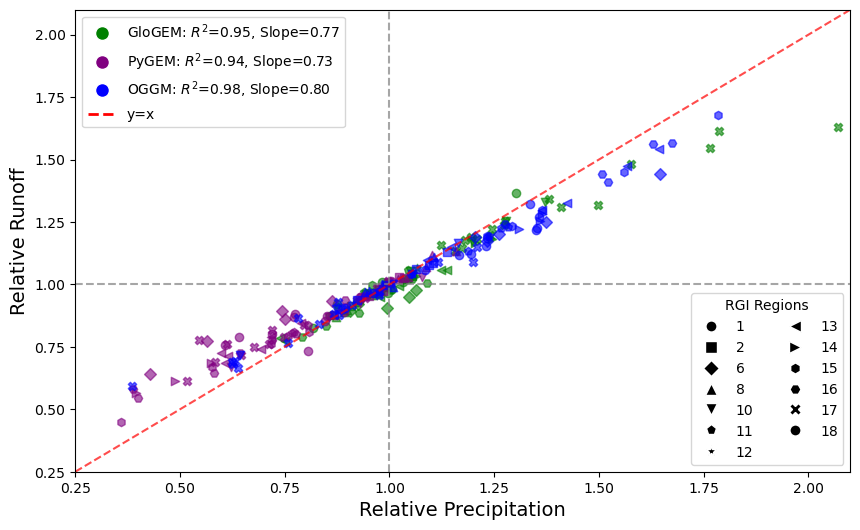

In [34]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression

# Define marker styles for RGI regions
region_markers = ['o', 's', 'D', '^', 'v', 'p', '*', '<', '>', 'h', 'H', 'X']  # Add more markers if needed
rgi_region_to_marker = {region: region_markers[i % len(region_markers)] for i, region in enumerate(set(basin_to_region.values()))}

chosen_SSP = 'ssp245'

# Create scatter plot
plt.figure(figsize=(10, 6))

# Remove specified basins
rmq_data = RMQs[chosen_SSP]
precip_data = normalized_prcp_values

# List to store regression results
regression_results = []

# Scatter plot for each glacier model
for gmodel, color in zip(gmodels, ['green', 'purple', 'blue']):
    x = precip_data[gmodel].values.reshape(-1, 1)
    y = rmq_data[gmodel]
    
    # Assign markers based on RGI regions
    for basin in rmq_data.index:
        region = basin_to_region.get(basin, None)  # Get RGI region, default None
        marker = rgi_region_to_marker.get(region, 'o')  # Get marker, default 'o'
        plt.scatter(precip_data[gmodel].loc[basin], rmq_data[gmodel].loc[basin], 
                    color=color, marker=marker, alpha=0.6)
    
    # Perform linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    r_squared = model.score(x, y)
    slope = model.coef_[0]

    regression_results.append({'Glacier Model': gmodel, 'R^2 Value': r_squared, 'Slope': slope})

# Convert the regression results to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Add grey dotted lines passing through x=1 and y=1
plt.axvline(x=1, color='grey', linestyle='--', alpha=0.7)
plt.axhline(y=1, color='grey', linestyle='--', alpha=0.7)
plt.plot([0.25, 2.1], [0.25, 2.1], color='red', linestyle='--', label='y=x', alpha=0.7)

# Labels and axis limits
plt.xlabel('Relative Precipitation', fontsize=14)
plt.ylabel('Relative Runoff', fontsize=14)
plt.xlim(0.25, 2.1)
plt.ylim(0.25, 2.1)

# Custom legend for RGI region markers (bottom-right)
region_legend = [Line2D([0], [0], marker=marker, color='w', markerfacecolor='black', 
                        markersize=8, label=f"{region}") 
                 for region, marker in rgi_region_to_marker.items()]
region_legend_handle = plt.legend(handles=region_legend, loc='lower right', fontsize=10, ncol =2, title="RGI Regions")

# Custom legend for regression results (upper-left)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f"{row['Glacier Model']}: $R^2$={row['R^2 Value']:.2f}, Slope={row['Slope']:.2f}", 
           markerfacecolor=color, markersize=10) 
    for (index, row), color in zip(regression_df.iterrows(), ['green', 'purple', 'blue'])
]
legend_elements.append(Line2D([0], [0], color='red', lw=2, linestyle='--', label='y=x'))
regression_legend_handle = plt.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Add both legends to the plot
plt.gca().add_artist(region_legend_handle)

# Save and show the plot
name = 'relativeRF_vs_relativePRCP_rgi'
plt.savefig(f"/Users/finnwimberly/Desktop/{name}.pdf", dpi=300, bbox_inches='tight')

plt.show()

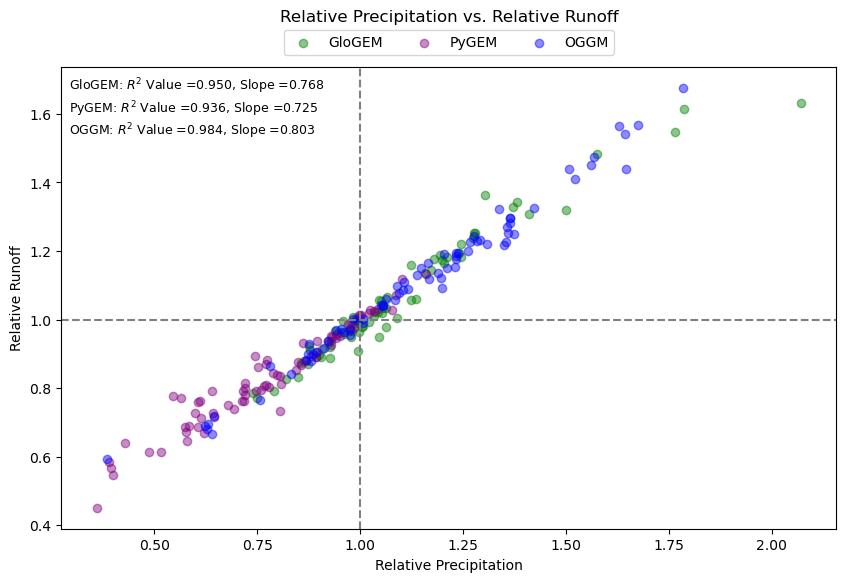

In [17]:
chosen_SSP = 'ssp245'

# Create scatter plot
plt.figure(figsize=(10, 6))

# Remove specified basins
rmq_data = RMQs[chosen_SSP]#.drop(index=basins_to_remove, errors='ignore')
precip_data = normalized_prcp_values#.drop(index=basins_to_remove, errors='ignore')

# List to store correlation coefficients and p-values
regression_results = []

# Scatter plot for each gmodel
for gmodel, color in zip(gmodels, ['green', 'purple', 'blue']):
    x = precip_data[gmodel].values.reshape(-1, 1)
    y = rmq_data[gmodel]
    plt.scatter(x, y, color=color, label=gmodel, alpha = 0.45)  # Add label for legend

    # Perform linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    
    # Calculate R^2 value
    r_squared = model.score(x, y)
    
    # Get slope of the line of best fit
    slope = model.coef_[0]

    regression_results.append({'Glacier Model': gmodel, 'R^2 Value': r_squared, 'Slope': slope})

# Convert the list of dictionaries to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Annotate correlation coefficients and p-values in the upper left corner
text = '\n'.join(f"{row['Glacier Model']}: $R^2$ Value ={row['R^2 Value']:.3f}, Slope ={row['Slope']:.3f}" for index, row in regression_df.iterrows())
plt.text(0.01, 0.98, text, transform=plt.gca().transAxes, fontsize=9, verticalalignment='top')

# Add grey dotted lines passing through x=1 and y=1
plt.axvline(x=1, color='grey', linestyle='--')
plt.axhline(y=1, color='grey', linestyle='--')

# Plot labels and legend
plt.xlabel('Relative Precipitation')
plt.ylabel('Relative Runoff')
plt.title('Relative Precipitation vs. Relative Runoff', y = 1.08)

# Modify legend to have three columns and position it above the plot
plt.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.01))

name = 'relativeRF_vs_relativePRCP'
plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/{name}.pdf", dpi=300, bbox_inches='tight')

plt.show()

Loading in hist mean RF data:

In [18]:
fpath0 = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/'

scenarios = ['ssp126','ssp245','ssp370','ssp585']

modelnames = ['BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 
                  'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']
RF_hist_mean = {}   
for s, SSP in enumerate(scenarios):
    RF_hist_mean[SSP] = {}
    for m, GCM in enumerate(modelnames):
        
        file = f"RF_hist_mean{GCM}_{SSP}.csv"
        temp_df = pd.read_csv(fpath0 + 'RF Historical Means/'+ file, index_col=0)
    
        # Store the combined_df in the dictionary for each SSP
        RF_hist_mean[SSP][GCM] = temp_df

In [19]:
#Create new dict to store multi-GCM means
hist_GCM_means = {}
for g, gmodel in enumerate(gmodels):
    hist_GCM_means[gmodel] = {}
    for s, SSP in enumerate(scenarios):
        all_GCMs = []
        for m, GCM in enumerate(modelnames):
            all_GCMs.append(RF_hist_mean[SSP][GCM][gmodel])
            
        # Calculate the mean for each year across the models
        temp_df = pd.DataFrame(all_GCMs)
        hist_GCM_means[gmodel][SSP] = temp_df.mean(axis = 0)

In [20]:
# Adjusting data structure to match precip data
RF_values = {}

for SSP in scenarios:
    SSP_data = {}
    for gmodel in gmodels:
        gmodel_data = hist_GCM_means[gmodel][SSP]
        SSP_data[gmodel] = gmodel_data
        
    # Create DataFrame for the SSP
    SSP_df = pd.DataFrame(SSP_data)
    
    # Store DataFrame in the restructured dictionary
    RF_values[SSP] = SSP_df

In [21]:
SSP_df

,GloGEM,PyGEM,OGGM
RHINE,1.323419,1.233576,1.780458
RHONE,3.191716,2.728216,3.660574
PO,1.034866,0.921519,1.280365
DANUBE,1.264153,1.227140,1.694774
TITICACA,0.613016,0.603711,1.054741
...,...,...,...
GANGES,21.517092,11.243828,41.843370
BRAHMAPUTRA,30.673658,25.251483,39.626843
OB,1.782087,1.556373,1.780521
INDIGIRKA,0.353800,0.328349,0.407898


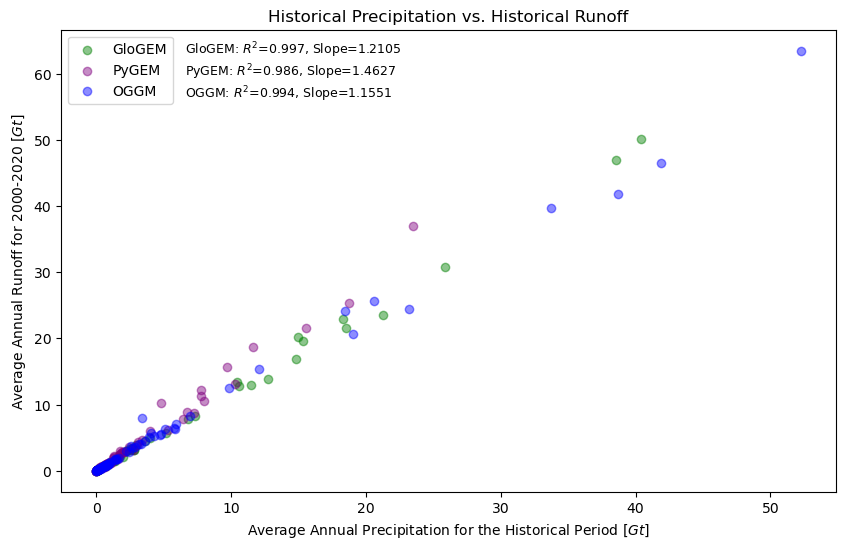

In [22]:
chosen_SSP = 'ssp245'

# Create scatter plot
plt.figure(figsize=(10, 6))

# List to store correlation coefficients, p-values, R^2 values, and slopes
regression_results = []

# Scatter plot for each gmodel
for gmodel, color in zip(gmodels, ['green', 'purple', 'blue']):
    x = all_precip_data[gmodel].values.reshape(-1, 1)
    y = RF_values[chosen_SSP][gmodel].values
    
    # Perform linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    
    # Calculate R^2 value
    r_squared = model.score(x, y)
    
    # Get slope of the line of best fit
    slope = model.coef_[0]
    
    plt.scatter(x, y, color=color, label=gmodel, alpha=0.45)
    #plt.plot(x, y_pred, color=color, linestyle='dotted', linewidth=1, alpha=0.45)

    regression_results.append({'Glacier Model': gmodel, 'R^2 Value': r_squared, 'Slope': slope})

# Convert the list of dictionaries to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Annotate R^2 values and slopes
text = '\n'.join(f"{row['Glacier Model']}: $R^2$={row['R^2 Value']:.3f}, Slope={row['Slope']:.4f}" for index, row in regression_df.iterrows())
plt.text(0.16, 0.979, text, transform=plt.gca().transAxes, fontsize=9, verticalalignment='top')

name = 'Historical Precipitation vs. Historical Runoff'

# Plot labels and legend
plt.xlabel(r'Average Annual Precipitation for the Historical Period $[Gt]$')
plt.ylabel(r'Average Annual Runoff for 2000-2020 $[Gt]$')
plt.title(f"{name}")
plt.legend()

plt.show()

Loading in mean RF data:

In [23]:
# Create an empty dictionary to store RMQ DataFrames for each GCM and SSP
fpath0 = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/'

scenarios = ['ssp126','ssp245','ssp370','ssp585']

modelnames = ['BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 
                  'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']
RF_mean = {}   
for s, SSP in enumerate(scenarios):
    RF_mean[SSP] = {}
    for m, GCM in enumerate(modelnames):
        
        file = f"RF_mean{GCM}_{SSP}.csv"
        temp_df = pd.read_csv(fpath0 + 'RF Means/'+ file, index_col=0)
    
        # Store the combined_df in the dictionary for each SSP
        RF_mean[SSP][GCM] = temp_df

In [24]:
#Create new dict to store multi-GCM means
RF_GCM_means = {}
for g, gmodel in enumerate(gmodels):
    RF_GCM_means[gmodel] = {}
    for s, SSP in enumerate(scenarios):
        all_GCMs = []
        for m, GCM in enumerate(modelnames):
            all_GCMs.append(RF_mean[SSP][GCM][gmodel])
            
        # Calculate the mean for each year across the models
        temp_df = pd.DataFrame(all_GCMs)
        RF_GCM_means[gmodel][SSP] = temp_df.median(axis = 0)

In [25]:
# Adjusting data structure to match precip data
RF_values = {}

for SSP in scenarios:
    SSP_data = {}
    for gmodel in gmodels:
        gmodel_data = RF_GCM_means[gmodel][SSP]
        SSP_data[gmodel] = gmodel_data
        
    # Create DataFrame for the SSP
    SSP_df = pd.DataFrame(SSP_data)
    
    # Calculate the median RF value for each row and add it as a new column
    SSP_df['Median_RF'] = SSP_df.median(axis=1)
    
    # Store DataFrame in the restructured dictionary
    RF_values[SSP] = SSP_df

In [26]:
RF_values[SSP]

,GloGEM,PyGEM,OGGM,Median_RF
RHINE,1.227953,1.037683,1.575081,1.227953
RHONE,3.078525,2.427074,3.340522,3.078525
PO,0.946847,0.791506,1.139794,0.946847
DANUBE,1.143921,1.042643,1.503011,1.143921
TITICACA,0.598646,0.520856,1.039408,0.598646
...,...,...,...,...
GANGES,22.834448,11.808405,45.118066,22.834448
BRAHMAPUTRA,32.303849,24.624901,40.445196,32.303849
OB,1.800482,1.555056,1.775089,1.775089
INDIGIRKA,0.319372,0.287629,0.384263,0.319372


In [27]:
#Exporting as a CSV
output_dir = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/Precipitation Analysis/'

for SSP in scenarios:
    fname = f"{SSP}_avgRF.csv"
    
    # Define the full path of the output file
    output_path = os.path.join(output_dir, fname)
    
    outdf = RF_values[SSP]
    
    # Save the DataFrame as CSV
    outdf.to_csv(output_path, header=True, index=True)

In [ ]:
chosen_SSP = 'ssp245'

# Create scatter plot
plt.figure(figsize=(10, 6))

# List to store correlation coefficients, p-values, R^2 values, and slopes
regression_results = []

# Scatter plot for each gmodel
for gmodel, color in zip(gmodels, ['green', 'purple', 'blue']):
    x = all_precip_data[gmodel].values.reshape(-1, 1)
    y = RF_values[chosen_SSP][gmodel].values
    
    # Perform linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    
    # Calculate R^2 value
    r_squared = model.score(x, y)
    
    # Get slope of the line of best fit
    slope = model.coef_[0]
    
    plt.scatter(x, y, color=color, label=gmodel, alpha=0.45)
    #plt.plot(x, y_pred, color=color, linestyle='dotted', linewidth=1, alpha=0.45)

    regression_results.append({'Glacier Model': gmodel, 'R^2 Value': r_squared, 'Slope': slope})

# Convert the list of dictionaries to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Annotate R^2 values and slopes
text = '\n'.join(f"{row['Glacier Model']}: $R^2$={row['R^2 Value']:.3f}, Slope={row['Slope']:.4f}" for index, row in regression_df.iterrows())
plt.text(0.16, 0.979, text, transform=plt.gca().transAxes, fontsize=9, verticalalignment='top')

name = 'Historical Precipitation vs. Average Runoff for 2000-2100'

# Plot labels and legend
plt.xlabel(r'Average Annual Precipitation for the Historical Period $[Gt]$')
plt.ylabel(r'Average Annual Runoff for 2000-2100 $[Gt]$')
plt.title(f"{name}")
plt.legend()

plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/{name}.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
chosen_SSP = 'ssp245'

# Create scatter plot
plt.figure(figsize=(10, 6))

# List to store correlation coefficients, p-values, R^2 values, and slopes
regression_results = []

# Scatter plot for each gmodel
for gmodel, color in zip(gmodels, ['green', 'purple', 'blue']):
    x = all_precip_data[gmodel].values.reshape(-1, 1)
    y = RF_values[chosen_SSP][gmodel].values
    
    # Perform linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    
    # Calculate R^2 value
    r_squared = model.score(x, y)
    
    # Get slope of the line of best fit
    slope = model.coef_[0]
    
    plt.scatter(x, y, color=color, label=gmodel, alpha=0.45)
    #plt.plot(x, y_pred, color=color, linestyle='dotted', linewidth=1, alpha=0.45)

    regression_results.append({'Glacier Model': gmodel, 'R^2 Value': r_squared, 'Slope': slope})

# Convert the list of dictionaries to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Annotate R^2 values and slopes
text = '\n'.join(f"{row['Glacier Model']}: $R^2$={row['R^2 Value']:.3f}, Slope={row['Slope']:.4f}" for index, row in regression_df.iterrows())
plt.text(0.01, 0.979, text, transform=plt.gca().transAxes, fontsize=9, verticalalignment='top')
#plt.text(0.99, 0, text, transform=plt.gca().transAxes, fontsize=9, verticalalignment='bottom', horizontalalignment='right')

# Plot labels and legend
plt.xlabel(r'Average Annual Precipitation for the Historical Period $[Gt]$')
plt.ylabel(r'Average Annual Runoff for 2000-2100 $[Gt]$')

#plt.xlim(0.7e-2, 100)

# Set log-log scale
plt.xscale('log')
plt.yscale('log')

plt.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.01))
plt.title('Historical Precipitation vs. Average Runoff for 2000-2100', y = 1.08)

name = 'RF_vs_PRCP'
plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/{name}.pdf", dpi=300, bbox_inches='tight')

plt.show()